In [ ]:
!pip install numpy scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

In [ ]:
# --- 1. Fungsi Keanggotaan (trimf) ---
def mu_trimf(x, a, b, c):
    """Fungsi Segitiga (trimf)"""
    return fuzz.trimf(np.asarray([x]), [a, b, c])[0]

In [ ]:
# --- 2. Input Data ---
x1 = 60 # soil_moisture
x2 = 26 # avg_temp

In [ ]:
# --- 3. Parameter Konsekuen (Sudah Dilatih) ---
# [p, q, r]
params = {
    'R1': [0.0692, 0.0461, 0.00231],
    'R2': [0.0698, 0.0390, 0.00139],
    'R3': [0.0585, 0.0183, 0.00084],
    'R4': [0.0505, 0.0318, 0.00115]
}

In [ ]:
# --- 4. Fuzzifikasi ---
# x1: Low = trimf(0,30,60), High = trimf(40,70,100)
mu_x1_low = mu_trimf(x1, 0, 30, 60)
mu_x1_high = mu_trimf(x1, 40, 70, 100)

# x2: Low = trimf(15,20,25), High = trimf(22,28,35)
mu_x2_low = mu_trimf(x2, 15, 20, 25)
mu_x2_high = mu_trimf(x2, 22, 28, 35)

In [ ]:
# --- 5. Inferensi (Perhitungan w_i) ---
w = {}
w['R1'] = min(mu_x1_low, mu_x2_low)
w['R2'] = min(mu_x1_low, mu_x2_high)
w['R3'] = min(mu_x1_high, mu_x2_low)
w['R4'] = min(mu_x1_high, mu_x2_high)

In [ ]:
# --- 6. Konsekuen (Perhitungan y_i) ---
y = {}
for rule, pqr in params.items():
    p, q, r = pqr
    y[rule] = p * x1 + q * x2 + r

In [ ]:
# --- 7. Defuzzifikasi (Output Akhir Y) ---
numerator = 0
denominator = 0

print("="*50)
print(f"Input: x1={x1}, x2={x2}")
print("Derajat Keanggotaan:")
print(f"mu_x1_low={mu_x1_low:.4f}, mu_x1_high={mu_x1_high:.4f}")
print(f"mu_x2_low={mu_x2_low:.4f}, mu_x2_high={mu_x2_high:.4f}")
print("-"*50)

for i in range(1, 5):
    rule = f'R{i}'
    wi = w[rule]
    yi = y[rule]
    numerator += wi * yi
    denominator += wi
    print(f"{rule}: w={wi:.4f}, y={yi:.4f}")

if denominator > 0:
    Y = numerator / denominator
else:
    Y = 0 # Kasus jika semua rule tidak aktif

print("-"*50)
print(f"Total Pembilang (Σw*y): {numerator:.4f}")
print(f"Total Penyebut (Σw): {denominator:.4f}")
print(f"\nPREDIKSI PRODUKSI JAGUNG (ton/ha): {Y:.4f}")
print("="*50)

Input: x1=60, x2=26
Derajat Keanggotaan:
mu_x1_low=0.0000, mu_x1_high=0.6667
mu_x2_low=0.0000, mu_x2_high=0.6667
--------------------------------------------------
R1: w=0.0000, y=5.3529
R2: w=0.0000, y=5.2034
R3: w=0.0000, y=3.9866
R4: w=0.6667, y=3.8580
--------------------------------------------------
Total Pembilang (Σw*y): 2.5720
Total Penyebut (Σw): 0.6667

PREDIKSI PRODUKSI JAGUNG (ton/ha): 3.8579


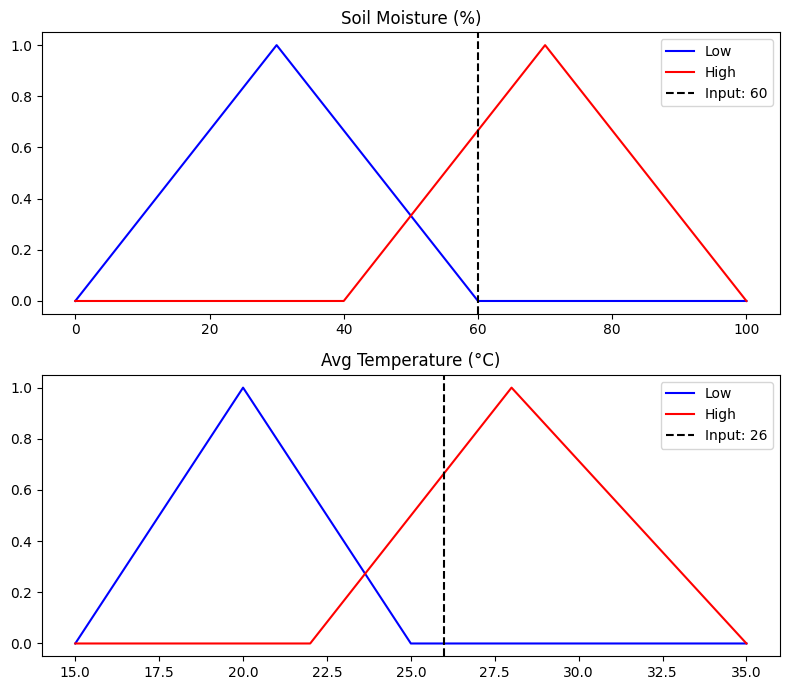

In [ ]:
# Range semesta berdasarkan soal
x_moisture = np.arange(0, 101, 1) # domain [0, 100] [cite: 68]
x_temp = np.arange(15, 36, 1)     # domain [15, 35] [cite: 72]

# Definisi MF berdasarkan soal [cite: 69, 71, 74, 75]
moist_low = fuzz.trimf(x_moisture, [0, 30, 60])
moist_high = fuzz.trimf(x_moisture, [40, 70, 100])

temp_low = fuzz.trimf(x_temp, [15, 20, 25])
temp_high = fuzz.trimf(x_temp, [22, 28, 35])

# Plotting
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(8, 7))

ax0.plot(x_moisture, moist_low, 'b', label='Low')
ax0.plot(x_moisture, moist_high, 'r', label='High')
ax0.axvline(x=60, color='k', linestyle='--', label='Input: 60')
ax0.set_title('Soil Moisture (%)')
ax0.legend()

ax1.plot(x_temp, temp_low, 'b', label='Low')
ax1.plot(x_temp, temp_high, 'r', label='High')
ax1.axvline(x=26, color='k', linestyle='--', label='Input: 26')
ax1.set_title('Avg Temperature (°C)')
ax1.legend()

plt.tight_layout()
plt.show()